# Fraud Yelp: symmetric degree-normalized similarity-weighted MPLE

This notebook corrects the previous row-normalized graph term. The corrected interaction normalizes by both endpoints:
$$
\frac{A_{ij}^{(r)} w_{ij}^{(r)}}{\sqrt{D_i^{(r)}D_j^{(r)}}},
\qquad
D_i^{(r)}=\sum_k A_{ik}^{(r)}w_{ik}^{(r)}.
$$


In [2]:
%matplotlib inline

from pathlib import Path
import importlib.util
import urllib.request
import zipfile
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import pandas as pd
from scipy import sparse
from scipy.io import loadmat
from scipy.sparse.csgraph import connected_components

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    PrecisionRecallDisplay,
    recall_score,
    RocCurveDisplay,
    roc_auc_score,
    precision_recall_curve
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

try:
    from IPython.display import display
except ImportError:
    display = print

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
warnings.filterwarnings("ignore", category=UserWarning)

In [1]:
!pip install dgl
!pip install torchdata==0.9.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 130.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 11.4 MB/s eta 0:00:00
  Attempting uninstall: torchdata
    Found existing installation: torchdata 0.11.0
    Uninstalling torchdata-0.11.0:
      Successfully uninstalled torchdata-0.11.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchtune 0.6.1 requires torchdata==0.11.0, but you have torchdata 0.9.0 which is incompatible.


In [5]:
!pip install torchdata

In [7]:
from dgl.data import FraudYelpDataset

In [8]:
import random, copy
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, confusion_matrix
)
from scipy.stats import beta as beta_dist

from dgl.data import FraudYelpDataset

SEED = 717
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## Corrected model

The corrected model is
$$
\mathbb P_{\beta,\theta}(\sigma\mid X,G_1,G_2,G_3)
\propto
\exp\left\{
\sum_{r=1}^3
\beta_r
\sum_{i<j}
\frac{
A_{ij}^{(r)}
\exp\left(-\frac{\|X_i-X_j\|_2^2}{2\tau_r^2}\right)
}{
\sqrt{
\left[\sum_{k=1}^n A_{ik}^{(r)}
\exp\left(-\frac{\|X_i-X_k\|_2^2}{2\tau_r^2}\right)+\varepsilon\right]
\left[\sum_{k=1}^n A_{jk}^{(r)}
\exp\left(-\frac{\|X_j-X_k\|_2^2}{2\tau_r^2}\right)+\varepsilon\right]
}
}
\sigma_i\sigma_j
+
2\sum_{i=1}^n\sigma_i b_\theta(X_i)
\right\}.
$$

The notebook trains the corresponding pseudo-likelihood classifier. For validation/test prediction, only training labels are used as observed neighboring spins.


In [9]:
dataset = FraudYelpDataset(random_seed=SEED, train_size=0.7, val_size=0.1, verbose=True)
g = dataset[0]

print(g)
print("node types:", g.ntypes)
print("edge types:", g.etypes)
print("canonical edge types:", g.canonical_etypes)


/root/.dgl/yelp.zip:   0%|          | 0.00/18.0M [00:00<?, ?B/s]

Extracting file to /root/.dgl/yelp_a7a80596
Done saving data into cached files.
Graph(num_nodes={'review': 45954},
      num_edges={('review', 'net_rsr', 'review'): 6805486, ('review', 'net_rtr', 'review'): 1147232, ('review', 'net_rur', 'review'): 98630},
      metagraph=[('review', 'review', 'net_rsr'), ('review', 'review', 'net_rtr'), ('review', 'review', 'net_rur')])
node types: ['review']
edge types: ['net_rsr', 'net_rtr', 'net_rur']
canonical edge types: [('review', 'net_rsr', 'review'), ('review', 'net_rtr', 'review'), ('review', 'net_rur', 'review')]


In [10]:
def get_node_data(g, key, ntype=None):
    if ntype is None:
        if len(g.ntypes) != 1:
            raise ValueError("Pass ntype explicitly when graph has multiple node types.")
        ntype = g.ntypes[0]
    value = g.ndata[key]
    if isinstance(value, dict):
        return value[ntype]
    return value

ntype = g.ntypes[0]

X_raw = get_node_data(g, "feature", ntype).float()
y01 = get_node_data(g, "label", ntype).long()
train_mask = get_node_data(g, "train_mask", ntype).bool()
val_mask = get_node_data(g, "val_mask", ntype).bool()
test_mask = get_node_data(g, "test_mask", ntype).bool()

sigma_all = 2.0 * y01.float() - 1.0

summary = pd.DataFrame({
    "split": ["train", "validation", "test", "all"],
    "n": [int(train_mask.sum()), int(val_mask.sum()), int(test_mask.sum()), int(y01.numel())],
    "positives_label_1": [int(y01[train_mask].sum()), int(y01[val_mask].sum()), int(y01[test_mask].sum()), int(y01.sum())],
})
summary["positive_rate"] = summary["positives_label_1"] / summary["n"]
summary


,split,n,positives_label_1,positive_rate
0,train,32167,4726,0.146921
1,validation,4595,651,0.141676
2,test,9192,1300,0.141427
3,all,45954,6677,0.145297


In [11]:
EDGE_TYPES = ["net_rur", "net_rsr", "net_rtr"]
BETA_LABELS = ["beta_1: net_rur", "beta_2: net_rsr", "beta_3: net_rtr"]

missing = [e for e in EDGE_TYPES if e not in g.etypes]
if missing:
    raise ValueError(f"Missing expected edge types: {missing}. Present edge types: {g.etypes}")

for etype in EDGE_TYPES:
    print(f"{etype:8s}: {g.num_edges(etype=etype):,} directed edges")


net_rur : 98,630 directed edges
net_rsr : 6,805,486 directed edges
net_rtr : 1,147,232 directed edges


In [12]:
def standardize_with_train_stats(X, train_mask, eps=1e-12):
    X = X.float()
    mean = X[train_mask].mean(dim=0)
    std = X[train_mask].std(dim=0, unbiased=False).clamp_min(eps)
    return (X - mean) / std, mean, std

X, X_mean, X_std = standardize_with_train_stats(X_raw, train_mask)
print("raw feature shape:", tuple(X_raw.shape))
print("standardized feature shape:", tuple(X.shape))


raw feature shape: (45954, 32)
standardized feature shape: (45954, 32)


## Compute symmetric normalized graph signal

For each relation \(r\), the graph covariate used for node \(i\) is
$$
\sum_j
\frac{A_{ij}^{(r)}w_{ij}^{(r)}}{\sqrt{(D_i^{(r)}+\varepsilon)(D_j^{(r)}+\varepsilon)}}
\sigma_j^{\mathrm{obs}}.
$$
This is the corrected normalization: both endpoints \(i\) and \(j\) enter.


In [13]:
SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS = train_mask
# SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS = torch.ones_like(train_mask, dtype=torch.bool)  # oracle diagnostic

EDGE_CHUNK_SIZE = 500_000
TAU_SAMPLE_SIZE = 200_000
DEGREE_EPS = 1e-12

@torch.no_grad()
def estimate_relation_taus_from_edge_samples(g, X_for_similarity, edge_types, sample_size=200_000, seed=717, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    rng = np.random.default_rng(seed)
    X_dev = X_for_similarity.to(device).float()
    tau_values = []

    for etype in edge_types:
        src, dst = g.edges(etype=etype)
        m = src.numel()
        if m == 0:
            tau_values.append(1.0)
            continue
        k = min(sample_size, m)
        sample_idx = rng.choice(m, size=k, replace=False)
        src_s, dst_s = src[sample_idx].to(device), dst[sample_idx].to(device)
        dist = (X_dev[src_s] - X_dev[dst_s]).pow(2).sum(dim=1).sqrt()
        tau = torch.median(dist).item()
        if not np.isfinite(tau) or tau <= 1e-12:
            tau = float(dist.mean().item())
        if not np.isfinite(tau) or tau <= 1e-12:
            tau = 1.0
        tau_values.append(float(tau))

    return torch.tensor(tau_values, dtype=torch.float32)

@torch.no_grad()
def rbf_edge_weights(X_dev, src, dst, tau):
    dist2 = (X_dev[src] - X_dev[dst]).pow(2).sum(dim=1)
    return torch.exp(-dist2 / (2.0 * float(tau) ** 2))

@torch.no_grad()
def compute_weighted_degrees(g, X_for_similarity, edge_types, tau_values, chunk_size=500_000, eps=1e-12, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_dev = X_for_similarity.to(device).float()
    n = X_for_similarity.shape[0]
    degree_columns = []

    for r, etype in enumerate(edge_types):
        src_cpu, dst_cpu = g.edges(etype=etype)
        deg = torch.zeros(n, dtype=torch.float32, device=device)
        tau_r = float(tau_values[r])

        for start in range(0, src_cpu.numel(), chunk_size):
            end = min(start + chunk_size, src_cpu.numel())
            src = src_cpu[start:end].to(device)
            dst = dst_cpu[start:end].to(device)
            w = rbf_edge_weights(X_dev, src, dst, tau=tau_r)
            deg.index_add_(0, dst, w)

        degree_columns.append(deg.clamp_min(eps).cpu())

    return torch.stack(degree_columns, dim=1)

@torch.no_grad()
def compute_symmetric_normalized_neighbor_sums(
    g, sigma_all, observed_mask, X_for_similarity, edge_types, tau_values, weighted_degrees,
    chunk_size=500_000, eps=1e-12, device=None
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_dev = X_for_similarity.to(device).float()
    sigma_dev = sigma_all.to(device).float()
    obs_dev = observed_mask.to(device).bool()
    D_dev = weighted_degrees.to(device).float().clamp_min(eps)

    n = sigma_all.numel()
    columns = []

    for r, etype in enumerate(edge_types):
        src_cpu, dst_cpu = g.edges(etype=etype)
        out = torch.zeros(n, dtype=torch.float32, device=device)
        tau_r = float(tau_values[r])

        for start in range(0, src_cpu.numel(), chunk_size):
            end = min(start + chunk_size, src_cpu.numel())
            src = src_cpu[start:end].to(device)
            dst = dst_cpu[start:end].to(device)

            w = rbf_edge_weights(X_dev, src, dst, tau=tau_r)
            coeff = w / torch.sqrt(D_dev[dst, r] * D_dev[src, r])
            out.index_add_(0, dst, coeff * obs_dev[src].float() * sigma_dev[src])

        columns.append(out.cpu())

    return torch.stack(columns, dim=1)


In [14]:
tau_values = estimate_relation_taus_from_edge_samples(
    g=g, X_for_similarity=X, edge_types=EDGE_TYPES,
    sample_size=TAU_SAMPLE_SIZE, seed=SEED, device=device
)

pd.DataFrame({"edge_type": EDGE_TYPES, "tau_r": tau_values.numpy()})


,edge_type,tau_r
0,net_rur,6.746763
1,net_rsr,7.590441
2,net_rtr,7.569873


In [15]:
weighted_degrees = compute_weighted_degrees(
    g=g, X_for_similarity=X, edge_types=EDGE_TYPES, tau_values=tau_values,
    chunk_size=EDGE_CHUNK_SIZE, eps=DEGREE_EPS, device=device
)

pd.DataFrame({
    "edge_type": EDGE_TYPES,
    "mean_weighted_degree_train": weighted_degrees[train_mask].mean(dim=0).numpy(),
    "median_weighted_degree_train": weighted_degrees[train_mask].median(dim=0).values.numpy(),
    "fraction_zero_degree_train": (weighted_degrees[train_mask] <= DEGREE_EPS).float().mean(dim=0).numpy(),
})


,edge_type,mean_weighted_degree_train,median_weighted_degree_train,fraction_zero_degree_train
0,net_rur,1.296849,0.435305,0.483197
1,net_rsr,89.155891,89.288231,0.000839
2,net_rtr,15.040526,13.462770,0.011534


In [16]:
S_sym = compute_symmetric_normalized_neighbor_sums(
    g=g,
    sigma_all=sigma_all,
    observed_mask=SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS,
    X_for_similarity=X,
    edge_types=EDGE_TYPES,
    tau_values=tau_values,
    weighted_degrees=weighted_degrees,
    chunk_size=EDGE_CHUNK_SIZE,
    eps=DEGREE_EPS,
    device=device,
)

pd.DataFrame(S_sym[train_mask].numpy(), columns=EDGE_TYPES).describe().T


,count,mean,std,min,25%,50%,75%,max
net_rur,32167.0,-0.321315,0.451105,-1.175455,-0.747196,0.000000,0.000000,1.173919
net_rsr,32167.0,-0.496133,0.165480,-1.082110,-0.583313,-0.528763,-0.441541,1.037439
net_rtr,32167.0,-0.487052,0.218575,-1.484626,-0.615615,-0.507565,-0.382040,1.413651


## Model class

Set `EXTERNAL_FIELD = "linear"` or `EXTERNAL_FIELD = "neural"`.  
Set `BETA_CONSTRAINT = "unconstrained"` or `BETA_CONSTRAINT = "nonnegative"`.  
The graph coefficients use lasso regularization.


In [31]:
EXTERNAL_FIELD = "neural"          # one of {"linear", "neural"}
BETA_CONSTRAINT = "unconstrained" # one of {"unconstrained", "nonnegative"}

def inverse_softplus(y):
    y = torch.as_tensor(y, dtype=torch.float32)
    return y + torch.log(-torch.expm1(-y))

class SymmetricNormalizedMPLE(nn.Module):
    def __init__(
        self, n_features, n_relations=3, external_field="neural",
        hidden=64, dropout=0.2, beta_constraint="unconstrained"
    ):
        super().__init__()
        if external_field not in {"linear", "neural"}:
            raise ValueError("external_field must be 'linear' or 'neural'.")
        if beta_constraint not in {"unconstrained", "nonnegative"}:
            raise ValueError("beta_constraint must be 'unconstrained' or 'nonnegative'.")

        self.external_field = external_field
        self.beta_constraint = beta_constraint

        if beta_constraint == "unconstrained":
            self.beta_param = nn.Parameter(torch.zeros(n_relations))
        else:
            beta_init = torch.full((n_relations,), 1e-4)
            self.beta_param = nn.Parameter(inverse_softplus(beta_init))

        if external_field == "linear":
            self.gamma = nn.Parameter(torch.zeros(n_features + 1))
        else:
            self.field_net = nn.Sequential(
                nn.Linear(n_features, hidden),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden, hidden),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden, 1),
            )

    @property
    def beta(self):
        if self.beta_constraint == "unconstrained":
            return self.beta_param
        return F.softplus(self.beta_param)

    def field(self, X):
        if self.external_field == "linear":
            ones = torch.ones((X.shape[0], 1), dtype=X.dtype, device=X.device)
            X_aug = torch.cat([ones, X], dim=1)
            return X_aug @ self.gamma
        return self.field_net(X).squeeze(-1)

    def logits(self, S_sym, X):
        h = S_sym @ self.beta + 2.0 * self.field(X)
        return 2.0 * h

    def forward(self, S_sym, X):
        return self.logits(S_sym, X)


In [32]:
def compute_metrics(y_true, score, threshold):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score)
    pred = (score >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])

    out = {
        "threshold": float(threshold),
        "n": int(y_true.size),
        "positive_rate": float(y_true.mean()) if y_true.size > 0 else np.nan,
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "precision_pos": precision_score(y_true, pred, zero_division=0),
        "recall_pos": recall_score(y_true, pred, zero_division=0),
        "f1_pos": f1_score(y_true, pred, zero_division=0),
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    }
    if np.unique(y_true).size >= 2:
        out["roc_auc"] = roc_auc_score(y_true, score)
        out["average_precision"] = average_precision_score(y_true, score)
    else:
        out["roc_auc"] = np.nan
        out["average_precision"] = np.nan
    return out

@torch.no_grad()
def predict_prob(model, S_sym, X, device):
    model.eval()
    logits = model(S_sym.to(device).float(), X.to(device).float())
    return torch.sigmoid(logits).cpu()

def select_threshold(y_true, score, objective="balanced_accuracy", n_grid=1001):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score)
    thresholds = np.linspace(0.0, 1.0, n_grid)
    best_t, best_value = 0.5, -np.inf
    for t in thresholds:
        pred = (score >= t).astype(int)
        if objective == "balanced_accuracy":
            value = balanced_accuracy_score(y_true, pred)
        elif objective == "f1":
            value = f1_score(y_true, pred, zero_division=0)
        else:
            raise ValueError("objective must be 'balanced_accuracy' or 'f1'.")
        if value > best_value:
            best_t, best_value = float(t), value
    return best_t, best_value

def evaluate_splits(model, S_sym, X, y01, masks, threshold, device):
    prob = predict_prob(model, S_sym, X, device).numpy()
    y_np = y01.numpy().astype(int)
    rows = []
    for name, mask in masks.items():
        idx = mask.numpy().astype(bool)
        row = compute_metrics(y_np[idx], prob[idx], threshold)
        row["split"] = name
        rows.append(row)
    return pd.DataFrame(rows)


In [33]:
def train_symmetric_normalized_mple(
    S_sym, X, y01, train_mask, val_mask,
    external_field="neural", hidden=64, dropout=0.2,
    beta_constraint="unconstrained",
    lr=1e-3, weight_decay=1e-4, l1_beta=1e-4,
    max_epochs=1000, patience=100, use_pos_weight=False, device=None
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    S_dev, X_dev = S_sym.to(device).float(), X.to(device).float()
    y_dev = y01.to(device).float()
    train_mask_dev, val_mask_dev = train_mask.to(device).bool(), val_mask.to(device).bool()

    model = SymmetricNormalizedMPLE(
        n_features=X.shape[1],
        n_relations=S_sym.shape[1],
        external_field=external_field,
        hidden=hidden,
        dropout=dropout,
        beta_constraint=beta_constraint,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    if use_pos_weight:
        y_train = y01[train_mask].float()
        pos_weight_value = (y_train.numel() - y_train.sum()).item() / max(float(y_train.sum().item()), 1.0)
        pos_weight = torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
    else:
        pos_weight_value, pos_weight = None, None

    history = []
    best_state, best_val_loss, best_epoch, bad_epochs = None, float("inf"), -1, 0

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        logits = model(S_dev, X_dev)
        train_loss_data = F.binary_cross_entropy_with_logits(
            logits[train_mask_dev], y_dev[train_mask_dev], pos_weight=pos_weight
        )
        beta_penalty = l1_beta * model.beta.abs().sum()
        loss = train_loss_data + beta_penalty
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits_eval = model(S_dev, X_dev)
            train_loss_eval = F.binary_cross_entropy_with_logits(
                logits_eval[train_mask_dev], y_dev[train_mask_dev]
            )
            val_loss = F.binary_cross_entropy_with_logits(
                logits_eval[val_mask_dev], y_dev[val_mask_dev]
            )

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss_eval.item()),
            "val_loss": float(val_loss.item()),
            "beta_1": float(model.beta.detach().cpu()[0]),
            "beta_2": float(model.beta.detach().cpu()[1]),
            "beta_3": float(model.beta.detach().cpu()[2]),
            "l1_beta_penalty": float(beta_penalty.detach().cpu().item()),
        })

        if val_loss.item() < best_val_loss - 1e-6:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch % 50 == 0:
            print(
                f"epoch={epoch:4d} train_loss={train_loss_eval.item():.5f} "
                f"val_loss={val_loss.item():.5f} beta={model.beta.detach().cpu().numpy()}"
            )

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    fit_info = {
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "pos_weight": pos_weight_value,
        "external_field": external_field,
        "beta_constraint": beta_constraint,
        "l1_beta": l1_beta,
    }
    return model, pd.DataFrame(history), fit_info


In [34]:
USE_POS_WEIGHT = False

model, history_df, fit_info = train_symmetric_normalized_mple(
    S_sym=S_sym,
    X=X,
    y01=y01,
    train_mask=train_mask,
    val_mask=val_mask,
    external_field=EXTERNAL_FIELD,
    hidden=64,
    dropout=0.2,
    beta_constraint=BETA_CONSTRAINT,
    lr=1e-3,
    weight_decay=1e-4,
    l1_beta=1e-4,
    max_epochs=1000,
    patience=100,
    use_pos_weight=USE_POS_WEIGHT,
    device=device,
)

fit_info


epoch=   0 train_loss=0.65543 val_loss=0.65570 beta=[0.001 0.001 0.001]
epoch=  50 train_loss=0.35359 val_loss=0.35117 beta=[0.04056806 0.02338529 0.02084665]
epoch= 100 train_loss=0.32535 val_loss=0.32652 beta=[0.07970615 0.0391723  0.03200861]
epoch= 150 train_loss=0.30654 val_loss=0.31298 beta=[0.1191994  0.05636663 0.04377327]
epoch= 200 train_loss=0.29337 val_loss=0.30332 beta=[0.1585646  0.07473914 0.05616345]
epoch= 250 train_loss=0.28406 val_loss=0.29566 beta=[0.19778873 0.0942703  0.06917327]
epoch= 300 train_loss=0.27585 val_loss=0.28834 beta=[0.23674788 0.11471694 0.08265126]
epoch= 350 train_loss=0.26829 val_loss=0.28176 beta=[0.27529317 0.13587178 0.0964254 ]
epoch= 400 train_loss=0.26110 val_loss=0.27560 beta=[0.31339222 0.15762667 0.11046207]
epoch= 450 train_loss=0.25394 val_loss=0.26990 beta=[0.35085562 0.17980635 0.12462239]
epoch= 500 train_loss=0.24680 val_loss=0.26351 beta=[0.38764858 0.20245518 0.13896573]
epoch= 550 train_loss=0.23914 val_loss=0.25689 beta=[0.423

{'best_epoch': 999,
 'best_val_loss': 0.21650715172290802,
 'pos_weight': None,
 'external_field': 'neural',
 'beta_constraint': 'unconstrained',
 'l1_beta': 0.0001}

In [35]:
history_df.tail()


,epoch,train_loss,val_loss,beta_1,beta_2,beta_3,l1_beta_penalty
995,995,0.190822,0.216755,0.710207,0.427199,0.274148,0.000141
996,996,0.190698,0.216657,0.710798,0.427634,0.274383,0.000141
997,997,0.190590,0.216557,0.711388,0.428071,0.274620,0.000141
998,998,0.190532,0.216540,0.711978,0.428508,0.274859,0.000141
999,999,0.190463,0.216507,0.712569,0.428944,0.275096,0.000142


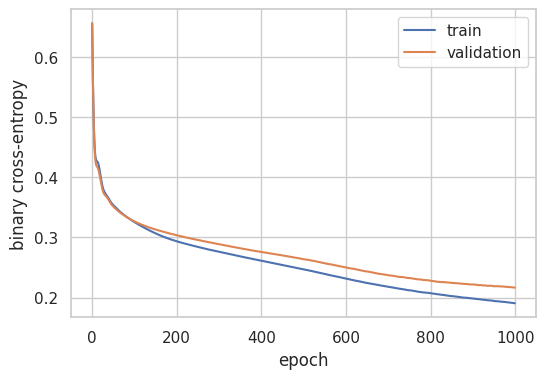

In [36]:
plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="validation")
plt.xlabel("epoch")
plt.ylabel("binary cross-entropy")
plt.legend()
plt.show()


In [37]:
with torch.no_grad():
    beta_hat = model.beta.detach().cpu()
    beta_param_hat = model.beta_param.detach().cpu()

beta_df = pd.DataFrame({
    "parameter": BETA_LABELS,
    "estimate_beta": beta_hat.numpy(),
    "internal_beta_param": beta_param_hat.numpy(),
    "constraint": BETA_CONSTRAINT,
})
beta_df


,parameter,estimate_beta,internal_beta_param,constraint
0,beta_1: net_rur,0.712569,0.712569,unconstrained
1,beta_2: net_rsr,0.428944,0.428944,unconstrained
2,beta_3: net_rtr,0.275096,0.275096,unconstrained


In [38]:
masks = {"train": train_mask, "validation": val_mask, "test": test_mask}

metrics_05 = evaluate_splits(
    model=model, S_sym=S_sym, X=X, y01=y01, masks=masks, threshold=0.5, device=device
)
metrics_05


,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,tn,fp,fn,tp,roc_auc,average_precision,split
0,0.5,32167,0.146921,0.927037,0.779892,0.893483,0.571519,0.697122,27119,322,2025,2701,0.953010,0.840739,train
1,0.5,4595,0.141676,0.916431,0.746111,0.837975,0.508449,0.632887,3880,64,320,331,0.927826,0.765530,validation
2,0.5,9192,0.141427,0.917211,0.749714,0.835616,0.516154,0.638136,7760,132,629,671,0.930746,0.766819,test


In [39]:
prob = predict_prob(model, S_sym, X, device).numpy()
y_np = y01.numpy().astype(int)
val_idx = val_mask.numpy().astype(bool)

best_t_balacc, best_val_balacc = select_threshold(
    y_true=y_np[val_idx], score=prob[val_idx], objective="balanced_accuracy"
)
best_t_f1, best_val_f1 = select_threshold(
    y_true=y_np[val_idx], score=prob[val_idx], objective="f1"
)

print("Best validation threshold for balanced accuracy:", best_t_balacc, "value:", best_val_balacc)
print("Best validation threshold for F1:", best_t_f1, "value:", best_val_f1)


Best validation threshold for balanced accuracy: 0.161 value: 0.8504041216041478
Best validation threshold for F1: 0.34500000000000003 value: 0.6972176759410802


In [40]:
metrics_val_balacc = evaluate_splits(
    model=model, S_sym=S_sym, X=X, y01=y01, masks=masks,
    threshold=best_t_balacc, device=device
)
metrics_val_balacc


,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,tn,fp,fn,tp,roc_auc,average_precision,split
0,0.161,32167,0.146921,0.878260,0.884859,0.552997,0.894202,0.683376,24025,3416,500,4226,0.953010,0.840739,train
1,0.161,4595,0.141676,0.856583,0.850404,0.496377,0.841782,0.624501,3388,556,103,548,0.927826,0.765530,validation
2,0.161,9192,0.141427,0.860313,0.850545,0.503704,0.836923,0.628902,6820,1072,212,1088,0.930746,0.766819,test


In [28]:
metrics_val_f1 = evaluate_splits(
    model=model, S_sym=S_sym, X=X, y01=y01, masks=masks,
    threshold=best_t_f1, device=device
)
metrics_val_f1


,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,tn,fp,fn,tp,roc_auc,average_precision,split
0,0.254,32167,0.146921,0.860198,0.756394,0.520702,0.609395,0.561568,24790,2651,1846,2880,0.868967,0.603129,train
1,0.254,4595,0.141676,0.861371,0.757002,0.508951,0.611367,0.555478,3560,384,253,398,0.869811,0.583519,validation
2,0.254,9192,0.141427,0.862163,0.757171,0.510611,0.610769,0.556217,7131,761,506,794,0.869794,0.595550,test


# Ablation study 1: use partial dataset

In [41]:
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_symmetric_normalized_mple(
    S_sym, X, y01, train_mask, val_mask,
    relation_names=None,
    external_field="neural", hidden=64, dropout=0.2,
    beta_constraint="unconstrained",
    lr=1e-3, weight_decay=1e-4, l1_beta=1e-4,
    max_epochs=1000, patience=100, use_pos_weight=False,
    seed=717,
    device=None,
    verbose=True,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    set_all_seeds(seed)

    if relation_names is None:
        relation_names = [f"rel_{i}" for i in range(S_sym.shape[1])]

    S_dev = S_sym.to(device).float()
    X_dev = X.to(device).float()
    y_dev = y01.to(device).float()
    train_mask_dev = train_mask.to(device).bool()
    val_mask_dev = val_mask.to(device).bool()

    model = SymmetricNormalizedMPLE(
        n_features=X.shape[1],
        n_relations=S_sym.shape[1],
        external_field=external_field,
        hidden=hidden,
        dropout=dropout,
        beta_constraint=beta_constraint,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    if use_pos_weight:
        y_train = y01[train_mask].float()
        pos_weight_value = (y_train.numel() - y_train.sum()).item() / max(float(y_train.sum().item()), 1.0)
        pos_weight = torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
    else:
        pos_weight_value = None
        pos_weight = None

    history = []
    best_state = None
    best_val_loss = float("inf")
    best_epoch = -1
    bad_epochs = 0

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        logits = model(S_dev, X_dev)

        train_loss_data = F.binary_cross_entropy_with_logits(
            logits[train_mask_dev],
            y_dev[train_mask_dev],
            pos_weight=pos_weight,
        )

        beta_penalty = l1_beta * model.beta.abs().sum()
        loss = train_loss_data + beta_penalty

        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits_eval = model(S_dev, X_dev)

            train_loss_eval = F.binary_cross_entropy_with_logits(
                logits_eval[train_mask_dev],
                y_dev[train_mask_dev],
            )

            val_loss = F.binary_cross_entropy_with_logits(
                logits_eval[val_mask_dev],
                y_dev[val_mask_dev],
            )

        beta_values = model.beta.detach().cpu().numpy()

        row = {
            "epoch": epoch,
            "train_loss": float(train_loss_eval.item()),
            "val_loss": float(val_loss.item()),
            "l1_beta_penalty": float(beta_penalty.detach().cpu().item()),
        }

        for name, value in zip(relation_names, beta_values):
            row[f"beta_{name}"] = float(value)

        history.append(row)

        if val_loss.item() < best_val_loss - 1e-6:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if verbose and epoch % 50 == 0:
            print(
                f"epoch={epoch:4d} "
                f"train_loss={train_loss_eval.item():.5f} "
                f"val_loss={val_loss.item():.5f} "
                f"beta={beta_values}"
            )

        if bad_epochs >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    fit_info = {
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "pos_weight": pos_weight_value,
        "external_field": external_field,
        "beta_constraint": beta_constraint,
        "l1_beta": l1_beta,
        "relations": relation_names,
        "seed": seed,
    }

    return model, pd.DataFrame(history), fit_info

In [42]:
import itertools

EDGE_TO_COL = {etype: i for i, etype in enumerate(EDGE_TYPES)}

ABLATION_SPECS = {
    "all_3_edges": ["net_rur", "net_rsr", "net_rtr"],

    # leave-one-edge-out ablations
    "no_net_rur": ["net_rsr", "net_rtr"],
    "no_net_rsr": ["net_rur", "net_rtr"],
    "no_net_rtr": ["net_rur", "net_rsr"],

    # single-edge ablations
    "only_net_rur": ["net_rur"],
    "only_net_rsr": ["net_rsr"],
    "only_net_rtr": ["net_rtr"],
}


def select_edge_columns(S_sym, edge_types):
    cols = [EDGE_TO_COL[e] for e in edge_types]
    return S_sym[:, cols]


def run_one_ablation(
    ablation_name,
    edge_types_used,
    seed=717,
    external_field="linear",
    beta_constraint="unconstrained",
    hidden=64,
    dropout=0.2,
    lr=1e-3,
    weight_decay=1e-4,
    l1_beta=1e-4,
    max_epochs=1000,
    patience=100,
    use_pos_weight=False,
    device=None,
    verbose=False,
):
    S_ablate = select_edge_columns(S_sym, edge_types_used)

    model, history_df, fit_info = train_symmetric_normalized_mple(
        S_sym=S_ablate,
        X=X,
        y01=y01,
        train_mask=train_mask,
        val_mask=val_mask,
        relation_names=edge_types_used,
        external_field=external_field,
        hidden=hidden,
        dropout=dropout,
        beta_constraint=beta_constraint,
        lr=lr,
        weight_decay=weight_decay,
        l1_beta=l1_beta,
        max_epochs=max_epochs,
        patience=patience,
        use_pos_weight=use_pos_weight,
        seed=seed,
        device=device,
        verbose=verbose,
    )

    masks = {
        "train": train_mask,
        "validation": val_mask,
        "test": test_mask,
    }

    prob = predict_prob(model, S_ablate, X, device).numpy()
    y_np = y01.numpy().astype(int)
    val_idx = val_mask.numpy().astype(bool)

    best_t_balacc, best_val_balacc = select_threshold(
        y_true=y_np[val_idx],
        score=prob[val_idx],
        objective="balanced_accuracy",
    )

    best_t_f1, best_val_f1 = select_threshold(
        y_true=y_np[val_idx],
        score=prob[val_idx],
        objective="f1",
    )

    metrics_05 = evaluate_splits(
        model=model,
        S_sym=S_ablate,
        X=X,
        y01=y01,
        masks=masks,
        threshold=0.5,
        device=device,
    )
    metrics_05["threshold_strategy"] = "fixed_0.5"

    metrics_balacc = evaluate_splits(
        model=model,
        S_sym=S_ablate,
        X=X,
        y01=y01,
        masks=masks,
        threshold=best_t_balacc,
        device=device,
    )
    metrics_balacc["threshold_strategy"] = "val_balanced_accuracy"

    metrics_f1 = evaluate_splits(
        model=model,
        S_sym=S_ablate,
        X=X,
        y01=y01,
        masks=masks,
        threshold=best_t_f1,
        device=device,
    )
    metrics_f1["threshold_strategy"] = "val_f1"

    metrics_df = pd.concat(
        [metrics_05, metrics_balacc, metrics_f1],
        ignore_index=True,
    )

    metrics_df["ablation"] = ablation_name
    metrics_df["edge_types_used"] = ",".join(edge_types_used)
    metrics_df["n_edge_types"] = len(edge_types_used)
    metrics_df["seed"] = seed

    with torch.no_grad():
        beta_hat = model.beta.detach().cpu().numpy()

    beta_df = pd.DataFrame({
        "ablation": ablation_name,
        "seed": seed,
        "edge_type": edge_types_used,
        "beta_hat": beta_hat,
    })

    fit_row = {
        "ablation": ablation_name,
        "seed": seed,
        "edge_types_used": ",".join(edge_types_used),
        "n_edge_types": len(edge_types_used),
        "best_epoch": fit_info["best_epoch"],
        "best_val_loss": fit_info["best_val_loss"],
        "best_threshold_balacc": best_t_balacc,
        "best_val_balacc": best_val_balacc,
        "best_threshold_f1": best_t_f1,
        "best_val_f1": best_val_f1,
        "external_field": external_field,
        "beta_constraint": beta_constraint,
        "l1_beta": l1_beta,
    }

    return {
        "model": model,
        "history": history_df,
        "metrics": metrics_df,
        "beta": beta_df,
        "fit": fit_row,
        "prob": prob,
    }

In [43]:
ABLATION_SEEDS = [SEED]
# For more stable results, use something like:
# ABLATION_SEEDS = [717, 718, 719, 720, 721]

ablation_outputs = {}

all_metrics = []
all_betas = []
all_fits = []

for ablation_name, edge_types_used in ABLATION_SPECS.items():
    for seed in ABLATION_SEEDS:
        print(f"\nRunning ablation={ablation_name}, seed={seed}, edges={edge_types_used}")

        out = run_one_ablation(
            ablation_name=ablation_name,
            edge_types_used=edge_types_used,
            seed=seed,
            external_field=EXTERNAL_FIELD,
            beta_constraint=BETA_CONSTRAINT,
            hidden=64,
            dropout=0.2,
            lr=1e-3,
            weight_decay=1e-4,
            l1_beta=1e-4,
            max_epochs=1000,
            patience=100,
            use_pos_weight=USE_POS_WEIGHT,
            device=device,
            verbose=False,
        )

        ablation_outputs[(ablation_name, seed)] = out
        all_metrics.append(out["metrics"])
        all_betas.append(out["beta"])
        all_fits.append(out["fit"])

ablation_metrics_df = pd.concat(all_metrics, ignore_index=True)
ablation_betas_df = pd.concat(all_betas, ignore_index=True)
ablation_fit_df = pd.DataFrame(all_fits)

ablation_metrics_df.head()


Running ablation=all_3_edges, seed=717, edges=['net_rur', 'net_rsr', 'net_rtr']

Running ablation=no_net_rur, seed=717, edges=['net_rsr', 'net_rtr']

Running ablation=no_net_rsr, seed=717, edges=['net_rur', 'net_rtr']

Running ablation=no_net_rtr, seed=717, edges=['net_rur', 'net_rsr']

Running ablation=only_net_rur, seed=717, edges=['net_rur']

Running ablation=only_net_rsr, seed=717, edges=['net_rsr']

Running ablation=only_net_rtr, seed=717, edges=['net_rtr']


,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,tn,fp,fn,tp,roc_auc,average_precision,split,threshold_strategy,ablation,edge_types_used,n_edge_types,seed
0,0.500,32167,0.146921,0.927037,0.779892,0.893483,0.571519,0.697122,27119,322,2025,2701,0.953010,0.840739,train,fixed_0.5,all_3_edges,"net_rur,net_rsr,net_rtr",3,717
1,0.500,4595,0.141676,0.916431,0.746111,0.837975,0.508449,0.632887,3880,64,320,331,0.927826,0.765530,validation,fixed_0.5,all_3_edges,"net_rur,net_rsr,net_rtr",3,717
2,0.500,9192,0.141427,0.917211,0.749714,0.835616,0.516154,0.638136,7760,132,629,671,0.930746,0.766819,test,fixed_0.5,all_3_edges,"net_rur,net_rsr,net_rtr",3,717
3,0.161,32167,0.146921,0.878260,0.884859,0.552997,0.894202,0.683376,24025,3416,500,4226,0.953010,0.840739,train,val_balanced_accuracy,all_3_edges,"net_rur,net_rsr,net_rtr",3,717
4,0.161,4595,0.141676,0.856583,0.850404,0.496377,0.841782,0.624501,3388,556,103,548,0.927826,0.765530,validation,val_balanced_accuracy,all_3_edges,"net_rur,net_rsr,net_rtr",3,717


In [53]:
ablation_metrics_df[ablation_metrics_df.split == 'test'][ablation_metrics_df.threshold_strategy == 'val_f1'].sort_values(by='f1_pos', ascending=False)

,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,tn,fp,fn,tp,roc_auc,average_precision,split,threshold_strategy,ablation,edge_types_used,n_edge_types,seed
8,0.345,9192,0.141427,0.918516,0.809907,0.737295,0.658462,0.695652,7587,305,444,856,0.930746,0.766819,test,val_f1,all_3_edges,"net_rur,net_rsr,net_rtr",3,717
26,0.329,9192,0.141427,0.914600,0.815658,0.706496,0.677692,0.691794,7526,366,419,881,0.927995,0.754971,test,val_f1,no_net_rsr,"net_rur,net_rtr",2,717
35,0.362,9192,0.141427,0.917972,0.801880,0.744186,0.640000,0.688172,7606,286,468,832,0.929968,0.762140,test,val_f1,no_net_rtr,"net_rur,net_rsr",2,717
44,0.338,9192,0.141427,0.913077,0.807382,0.706173,0.660000,0.682306,7535,357,442,858,0.925771,0.749799,test,val_f1,only_net_rur,net_rur,1,717
53,0.321,9192,0.141427,0.895561,0.772124,0.639344,0.600000,0.619048,7452,440,520,780,0.891669,0.672229,test,val_f1,only_net_rsr,net_rsr,1,717
17,0.335,9192,0.141427,0.897302,0.765748,0.653713,0.582308,0.615948,7491,401,543,757,0.892047,0.677019,test,val_f1,no_net_rur,"net_rsr,net_rtr",2,717
62,0.346,9192,0.141427,0.894038,0.756780,0.642483,0.565385,0.601473,7483,409,565,735,0.887858,0.660800,test,val_f1,only_net_rtr,net_rtr,1,717


In [44]:
leaderboard = (
    ablation_metrics_df[
        (ablation_metrics_df["split"] == "test")
        & (ablation_metrics_df["threshold_strategy"] == "val_f1")
    ]
    .groupby(["ablation", "edge_types_used", "n_edge_types"], as_index=False)
    .agg(
        f1_pos_mean=("f1_pos", "mean"),
        f1_pos_std=("f1_pos", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        average_precision_mean=("average_precision", "mean"),
        average_precision_std=("average_precision", "std"),
        precision_pos_mean=("precision_pos", "mean"),
        recall_pos_mean=("recall_pos", "mean"),
    )
    .sort_values(
        by=["f1_pos_mean", "average_precision_mean", "balanced_accuracy_mean"],
        ascending=False,
    )
)

leaderboard

,ablation,edge_types_used,n_edge_types,f1_pos_mean,f1_pos_std,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,precision_pos_mean,recall_pos_mean
0,all_3_edges,"net_rur,net_rsr,net_rtr",3,0.695652,NaN,0.809907,NaN,0.930746,NaN,0.766819,NaN,0.737295,0.658462
1,no_net_rsr,"net_rur,net_rtr",2,0.691794,NaN,0.815658,NaN,0.927995,NaN,0.754971,NaN,0.706496,0.677692
2,no_net_rtr,"net_rur,net_rsr",2,0.688172,NaN,0.801880,NaN,0.929968,NaN,0.762140,NaN,0.744186,0.640000
6,only_net_rur,net_rur,1,0.682306,NaN,0.807382,NaN,0.925771,NaN,0.749799,NaN,0.706173,0.660000
4,only_net_rsr,net_rsr,1,0.619048,NaN,0.772124,NaN,0.891669,NaN,0.672229,NaN,0.639344,0.600000
3,no_net_rur,"net_rsr,net_rtr",2,0.615948,NaN,0.765748,NaN,0.892047,NaN,0.677019,NaN,0.653713,0.582308
5,only_net_rtr,net_rtr,1,0.601473,NaN,0.756780,NaN,0.887858,NaN,0.660800,NaN,0.642483,0.565385


In [45]:
leaderboard_balacc = (
    ablation_metrics_df[
        (ablation_metrics_df["split"] == "test")
        & (ablation_metrics_df["threshold_strategy"] == "val_balanced_accuracy")
    ]
    .groupby(["ablation", "edge_types_used", "n_edge_types"], as_index=False)
    .agg(
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        f1_pos_mean=("f1_pos", "mean"),
        f1_pos_std=("f1_pos", "std"),
        roc_auc_mean=("roc_auc", "mean"),
        average_precision_mean=("average_precision", "mean"),
        precision_pos_mean=("precision_pos", "mean"),
        recall_pos_mean=("recall_pos", "mean"),
    )
    .sort_values(
        by=["balanced_accuracy_mean", "average_precision_mean", "f1_pos_mean"],
        ascending=False,
    )
)

leaderboard_balacc

,ablation,edge_types_used,n_edge_types,balanced_accuracy_mean,balanced_accuracy_std,f1_pos_mean,f1_pos_std,roc_auc_mean,average_precision_mean,precision_pos_mean,recall_pos_mean
0,all_3_edges,"net_rur,net_rsr,net_rtr",3,0.850545,NaN,0.628902,NaN,0.930746,0.766819,0.503704,0.836923
2,no_net_rtr,"net_rur,net_rsr",2,0.849661,NaN,0.607230,NaN,0.929968,0.762140,0.469525,0.859231
1,no_net_rsr,"net_rur,net_rtr",2,0.849064,NaN,0.609435,NaN,0.927995,0.754971,0.473572,0.854615
6,only_net_rur,net_rur,1,0.848110,NaN,0.616596,NaN,0.925771,0.749799,0.486031,0.843077
3,no_net_rur,"net_rsr,net_rtr",2,0.804988,NaN,0.577527,NaN,0.892047,0.677019,0.469850,0.749231
4,only_net_rsr,net_rsr,1,0.801979,NaN,0.573717,NaN,0.891669,0.672229,0.466924,0.743846
5,only_net_rtr,net_rtr,1,0.797163,NaN,0.545953,NaN,0.887858,0.660800,0.424307,0.765385


## MCMC posterior marginals for GM weighted neural MPLE


In [29]:
# Model: h_i = sum_r beta_r S_sym_ir + 2 b_theta(X_i), with geometric/sqrt-degree normalized RBF-weighted interactions.

@torch.no_grad()
def fitted_external_field(model, X_field, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    X_dev = X_field.to(device).float()
    if hasattr(model, "field"):
        field = model.field(X_dev)
    elif hasattr(model, "gamma"):
        field = X_dev @ model.gamma
    else:
        raise AttributeError("Model must provide either field(X) or gamma for the external field.")
    return field.detach().cpu().numpy().astype(np.float64)


def unique_undirected_pairs_from_dgl(g, etype, n):
    src, dst = g.edges(etype=etype)
    src, dst = src.detach().cpu().long(), dst.detach().cpu().long()
    mask = src != dst
    lo = torch.minimum(src[mask], dst[mask])
    hi = torch.maximum(src[mask], dst[mask])
    keys = torch.unique(lo * n + hi)
    return (keys // n).long(), (keys % n).long()


def initial_graph_field_from_csr(sigma_np, csr):
    indptr, col, coef = csr["indptr"], csr["col"], csr["coef"]
    graph_field = np.zeros(len(indptr) - 1, dtype=np.float64)
    for i in range(len(graph_field)):
        start, end = indptr[i], indptr[i + 1]
        if end > start:
            graph_field[i] = np.dot(coef[start:end], sigma_np[col[start:end]])
    return graph_field


def summarize_gibbs_samples(samples, y01, fixed_mask, ci_level=0.95):
    num_samples, n = samples.shape
    successes = (samples == 1).sum(axis=0).astype(np.float64)
    p_hat = successes / num_samples
    alpha0 = 0.5
    lower_q = (1.0 - ci_level) / 2.0
    upper_q = 1.0 - lower_q
    ci_lower = beta_dist.ppf(lower_q, successes + alpha0, num_samples - successes + alpha0)
    ci_upper = beta_dist.ppf(upper_q, successes + alpha0, num_samples - successes + alpha0)
    fixed_mask_np = fixed_mask.detach().cpu().numpy().astype(bool)
    observed_label_np = y01.detach().cpu().numpy().astype(int)
    p_fixed = observed_label_np.astype(np.float64)
    p_hat[fixed_mask_np] = p_fixed[fixed_mask_np]
    ci_lower[fixed_mask_np] = p_fixed[fixed_mask_np]
    ci_upper[fixed_mask_np] = p_fixed[fixed_mask_np]
    return pd.DataFrame({
        "P_sigma_plus_1": p_hat,
        f"P_sigma_plus_1_ci_lower_{ci_level:.2f}": ci_lower,
        f"P_sigma_plus_1_ci_upper_{ci_level:.2f}": ci_upper,
        "E_sigma": samples.mean(axis=0),
        "Var_sigma": samples.var(axis=0, ddof=1) if num_samples > 1 else np.zeros(n),
        "observed_label": observed_label_np,
        "fixed_in_mcmc": fixed_mask_np,
    })


def run_gibbs_from_csr(csr, b_hat, y01, fixed_mask, burn_in_sweeps=500, num_samples=1000, thinning=10, ci_level=0.95, seed=717):
    rng = np.random.default_rng(seed)
    y01_cpu = y01.detach().cpu().long()
    fixed_mask_cpu = fixed_mask.detach().cpu().bool()
    fixed_mask_np = fixed_mask_cpu.numpy().astype(bool)
    free_idx = np.flatnonzero(~fixed_mask_np)
    fixed_spin = (2 * y01_cpu.numpy() - 1).astype(np.int8)
    sigma_np = rng.choice([-1, 1], size=int(y01.numel())).astype(np.int8)
    sigma_np[fixed_mask_np] = fixed_spin[fixed_mask_np]
    graph_field = initial_graph_field_from_csr(sigma_np, csr)
    indptr, col, coef = csr["indptr"], csr["col"], csr["coef"]
    samples, trace = [], []
    total_sweeps = burn_in_sweeps + num_samples * thinning
    for sweep in range(total_sweeps):
        rng.shuffle(free_idx)
        for i in free_idx:
            h_i = graph_field[i] + 2.0 * b_hat[i]
            p_plus = 1.0 / (1.0 + np.exp(-np.clip(2.0 * h_i, -60.0, 60.0)))
            old_spin = int(sigma_np[i])
            new_spin = 1 if rng.random() < p_plus else -1
            if new_spin != old_spin:
                delta = new_spin - old_spin
                sigma_np[i] = new_spin
                start, end = indptr[i], indptr[i + 1]
                np.add.at(graph_field, col[start:end], delta * coef[start:end])
        sigma_np[fixed_mask_np] = fixed_spin[fixed_mask_np]
        if sweep >= burn_in_sweeps and (sweep - burn_in_sweeps) % thinning == 0:
            samples.append(sigma_np.copy())
        if sweep == 0 or (sweep + 1) % max(1, total_sweeps // 10) == 0:
            trace.append({"sweep": sweep + 1, "mean_sigma": float(sigma_np.mean()), "positive_rate": float((sigma_np == 1).mean())})
            print(f"sweep {sweep + 1:4d} / {total_sweeps}")
    samples = np.asarray(samples, dtype=np.int8)
    return {"samples": samples, "posterior": summarize_gibbs_samples(samples, y01_cpu, fixed_mask_cpu, ci_level), "trace": pd.DataFrame(trace), "last_sigma": sigma_np.copy()}

@torch.no_grad()
def pair_similarity_weights(X_for_similarity, i_cpu, j_cpu, mode, tau=None, chunk_size=500_000, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_dev = X_for_similarity.to(device).float()
    weights = []
    for start in range(0, i_cpu.numel(), chunk_size):
        end = min(start + chunk_size, i_cpu.numel())
        i, j = i_cpu[start:end].to(device), j_cpu[start:end].to(device)
        if mode == "rbf_features":
            dist2 = (X_dev[i] - X_dev[j]).pow(2).sum(dim=1)
            w = torch.exp(-dist2 / (2.0 * float(tau) ** 2))
        elif mode == "cosine_positive":
            xi, xj = X_dev[i], X_dev[j]
            w = torch.clamp((xi * xj).sum(dim=1) / (xi.norm(dim=1).clamp_min(1e-12) * xj.norm(dim=1).clamp_min(1e-12)), min=0.0, max=1.0)
        else:
            raise ValueError("mode must be 'rbf_features' or 'cosine_positive'.")
        weights.append(w.detach().cpu())
    return torch.cat(weights).float()

@torch.no_grad()
def build_gm_weighted_csr(model, g, X_for_similarity, edge_types, similarity_mode, tau_values=None, chunk_size=500_000, eps=1e-12, device=None):
    n = X_for_similarity.shape[0]
    beta_hat = model.beta.detach().cpu().float()
    degrees = torch.zeros((n, len(edge_types)), dtype=torch.float32)
    pairs, weights = [], []
    for r, etype in enumerate(edge_types):
        i, j = unique_undirected_pairs_from_dgl(g, etype, n)
        tau_r = None if tau_values is None else float(tau_values[r])
        w = pair_similarity_weights(X_for_similarity, i, j, similarity_mode, tau_r, chunk_size, device)
        pairs.append((i, j)); weights.append(w)
        degrees[:, r].index_add_(0, i, w); degrees[:, r].index_add_(0, j, w)
    degrees = degrees.clamp_min(eps)
    row_parts, col_parts, coef_parts = [], [], []
    for r, (i, j) in enumerate(pairs):
        w, Di, Dj = weights[r], degrees[i, r], degrees[j, r]
        coef = beta_hat[r] * w / torch.sqrt(Di * Dj)
        row_parts.extend([i, j]); col_parts.extend([j, i]); coef_parts.extend([coef, coef])
    row, col, coef = torch.cat(row_parts).long(), torch.cat(col_parts).long(), torch.cat(coef_parts).float()
    order = torch.argsort(row); row, col, coef = row[order], col[order], coef[order]
    counts = torch.bincount(row, minlength=n)
    indptr = torch.zeros(n + 1, dtype=torch.long); indptr[1:] = torch.cumsum(counts, dim=0)
    return {"indptr": indptr.numpy().astype(np.int64), "col": col.numpy().astype(np.int64), "coef": coef.numpy().astype(np.float64), "degrees": degrees.numpy().astype(np.float64), "beta_hat": beta_hat.numpy().astype(np.float64)}


def gibbs_sample_gm_weighted_neural_mple(model, g, X_for_similarity, X_field, y01, fixed_mask, edge_types, similarity_mode, tau_values=None, burn_in_sweeps=500, num_samples=1000, thinning=10, ci_level=0.95, chunk_size=500_000, eps=1e-12, seed=717, device=None):
    b_hat = fitted_external_field(model, X_field, device=device)
    csr = build_gm_weighted_csr(model, g, X_for_similarity, edge_types, similarity_mode, tau_values, chunk_size, eps, device)
    out = run_gibbs_from_csr(csr, b_hat, y01, fixed_mask, burn_in_sweeps, num_samples, thinning, ci_level, seed)
    out.update({"beta_hat": csr["beta_hat"], "b_hat": b_hat, "degrees": csr["degrees"]})
    return out


In [30]:
MCMC_CONDITION_ON_TRAIN = True
MCMC_BURN_IN_SWEEPS = 500
MCMC_NUM_SAMPLES = 1000
MCMC_THINNING = 10
MCMC_CI_LEVEL = 0.95
MCMC_EPS = 1e-12
MCMC_SEED = 717

fixed_mask_mcmc = train_mask if MCMC_CONDITION_ON_TRAIN else torch.zeros_like(train_mask, dtype=torch.bool)


mcmc_results = gibbs_sample_gm_weighted_neural_mple(
    model=model, g=g, X_for_similarity=X, X_field=X, y01=y01,
    fixed_mask=fixed_mask_mcmc, edge_types=EDGE_TYPES, similarity_mode="rbf_features",
    tau_values=tau_values, burn_in_sweeps=MCMC_BURN_IN_SWEEPS,
    num_samples=MCMC_NUM_SAMPLES, thinning=MCMC_THINNING, ci_level=MCMC_CI_LEVEL,
    chunk_size=EDGE_CHUNK_SIZE, eps=MCMC_EPS, seed=MCMC_SEED, device=device,
)

mcmc_results["trace"].tail()


sweep    1 / 10500


KeyboardInterrupt: 

## Save MCMC outputs

Save posterior marginals, trace diagnostics, retained samples, and run metadata to Google Drive.


In [ ]:
# Edit ROWNAME before running if you want a custom label in the saved filenames.
ROWNAME = "S_gm_weighted_linear"

SAVE_MCMC_OUTPUTS_TO_GOOGLE_DRIVE = True
GOOGLE_DRIVE_MCMC_OUTPUT_DIR = "/content/drive/MyDrive/yelp/yelp_mcmc_outputs"

if SAVE_MCMC_OUTPUTS_TO_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    MCMC_OUTPUT_DIR = Path(GOOGLE_DRIVE_MCMC_OUTPUT_DIR)
else:
    MCMC_OUTPUT_DIR = Path("script/yelp/yelp_mcmc_outputs") if Path("script/yelp").exists() else Path("yelp_mcmc_outputs")

MCMC_OUTPUT_DIR = MCMC_OUTPUT_DIR / ROWNAME
MCMC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

posterior_path = MCMC_OUTPUT_DIR / f"{ROWNAME}_posterior.csv"
trace_path = MCMC_OUTPUT_DIR / f"{ROWNAME}_trace.csv"
samples_path = MCMC_OUTPUT_DIR / f"{ROWNAME}_sigma_samples.npz"
metadata_path = MCMC_OUTPUT_DIR / f"{ROWNAME}_metadata.json"

mcmc_results["posterior"].to_csv(posterior_path, index=True, index_label="node")
mcmc_results["trace"].to_csv(trace_path, index=False)

sample_payload = {
    "sigma_samples": mcmc_results["samples"],
    "samples": mcmc_results["samples"],  # backward-compatible alias
    "last_sigma": mcmc_results["last_sigma"],
}
for key in ["beta_hat", "beta_original_scale", "b_hat", "degrees"]:
    if key in mcmc_results:
        sample_payload[key] = mcmc_results[key]
np.savez_compressed(samples_path, **sample_payload)

mcmc_metadata = {
    "rowname": ROWNAME,
    "condition_on_train": MCMC_CONDITION_ON_TRAIN,
    "burn_in_sweeps": MCMC_BURN_IN_SWEEPS,
    "num_samples": MCMC_NUM_SAMPLES,
    "thinning": MCMC_THINNING,
    "ci_level": MCMC_CI_LEVEL,
    "eps": MCMC_EPS,
    "seed": MCMC_SEED,
    "posterior_path": str(posterior_path),
    "trace_path": str(trace_path),
    "samples_path": str(samples_path),
    "samples_shape": list(mcmc_results["samples"].shape),
    "samples_axis_0": "retained_mcmc_sample",
    "samples_axis_1": "node",
}
pd.Series(mcmc_metadata).to_json(metadata_path, indent=2)

print("Saved MCMC posterior to", posterior_path)
print("Saved MCMC trace to", trace_path)
print("Saved full retained sigma vectors to", samples_path)
print("sigma_samples shape:", mcmc_results["samples"].shape, "= (retained samples, nodes)")
print("Saved MCMC metadata to", metadata_path)


## Reload saved MCMC outputs

Load the saved posterior, trace, metadata, and full retained sigma vectors from the same output paths.


In [ ]:
loaded_posterior_df = pd.read_csv(posterior_path, index_col="node")
loaded_trace_df = pd.read_csv(trace_path)
loaded_samples_npz = np.load(samples_path)
loaded_sigma_samples = loaded_samples_npz["sigma_samples"]
loaded_metadata = pd.read_json(metadata_path, typ="series")

print("Loaded posterior shape:", loaded_posterior_df.shape)
print("Loaded trace shape:", loaded_trace_df.shape)
print("Loaded sigma samples shape:", loaded_sigma_samples.shape)
print("Loaded metadata from", metadata_path)

loaded_metadata


In [ ]:
posterior_df = mcmc_results["posterior"].copy()
posterior_df["train"] = train_mask.detach().cpu().numpy().astype(bool)
posterior_df["validation"] = val_mask.detach().cpu().numpy().astype(bool)
posterior_df["test"] = test_mask.detach().cpu().numpy().astype(bool)
posterior_df.loc[
    posterior_df["validation"] | posterior_df["test"],
    ["P_sigma_plus_1", "P_sigma_plus_1_ci_lower_0.95", "P_sigma_plus_1_ci_upper_0.95", "observed_label", "validation", "test"],
].head()


## MCMC sample covariance heatmap

Visualize posterior covariance between node spins using the retained Gibbs samples. The full Yelp node-by-node covariance matrix is too large to inspect directly, so this cell defaults to the most uncertain non-clamped nodes.


In [ ]:
CORR_NODE_POOL = "all_free"  # one of {"all_free", "validation", "test"}
CORR_NODE_SELECTION = "most_uncertain"  # one of {"most_uncertain", "random", "first"}
CORR_MAX_NODES = 250
CORR_RANDOM_SEED = 717

samples_for_corr = mcmc_results["samples"].astype(np.float64)
posterior_for_corr = mcmc_results["posterior"].copy()

fixed_for_corr = posterior_for_corr["fixed_in_mcmc"].to_numpy().astype(bool)
val_for_corr = val_mask.detach().cpu().numpy().astype(bool)
test_for_corr = test_mask.detach().cpu().numpy().astype(bool)

if CORR_NODE_POOL == "all_free":
    pool_mask = ~fixed_for_corr
elif CORR_NODE_POOL == "validation":
    pool_mask = val_for_corr & ~fixed_for_corr
elif CORR_NODE_POOL == "test":
    pool_mask = test_for_corr & ~fixed_for_corr
else:
    raise ValueError("CORR_NODE_POOL must be 'all_free', 'validation', or 'test'.")

candidate_nodes = np.flatnonzero(pool_mask)
if candidate_nodes.size == 0:
    raise ValueError("No non-clamped nodes available for the selected correlation pool.")

k = min(CORR_MAX_NODES, candidate_nodes.size)
if CORR_NODE_SELECTION == "most_uncertain":
    p_hat_for_corr = posterior_for_corr["P_sigma_plus_1"].to_numpy()
    uncertainty = p_hat_for_corr[candidate_nodes] * (1.0 - p_hat_for_corr[candidate_nodes])
    selected_nodes = candidate_nodes[np.argsort(uncertainty)[-k:]]
elif CORR_NODE_SELECTION == "random":
    rng = np.random.default_rng(CORR_RANDOM_SEED)
    selected_nodes = rng.choice(candidate_nodes, size=k, replace=False)
elif CORR_NODE_SELECTION == "first":
    selected_nodes = candidate_nodes[:k]
else:
    raise ValueError("CORR_NODE_SELECTION must be 'most_uncertain', 'random', or 'first'.")

selected_nodes = np.sort(selected_nodes)
selected_samples = samples_for_corr[:, selected_nodes]
node_std = selected_samples.std(axis=0)
nonconstant = node_std > 0
selected_nodes = selected_nodes[nonconstant]
selected_samples = selected_samples[:, nonconstant]

if selected_nodes.size < 2:
    raise ValueError("Need at least two nonconstant selected nodes to compute a correlation matrix.")

mean_sigma = selected_samples.mean(axis=0)
mean_outer = selected_samples.T @ selected_samples / selected_samples.shape[0]
cov_matrix = mean_outer - np.outer(mean_sigma, mean_sigma)

fig, ax = plt.subplots(figsize=(8, 7))
vmax = np.nanmax(np.abs(cov_matrix))
vmax = 0.01 if not np.isfinite(vmax) or vmax == 0 else vmax
im = ax.imshow(cov_matrix, cmap="vlag" if "sns" in globals() else "coolwarm", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.set_title(f"MCMC spin covariance: {selected_nodes.size} {CORR_NODE_SELECTION} nodes from {CORR_NODE_POOL}")
ax.set_xlabel("Selected node index")
ax.set_ylabel("Selected node index")

max_ticks = 12
tick_positions = np.linspace(0, selected_nodes.size - 1, min(max_ticks, selected_nodes.size), dtype=int)
ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)
ax.set_xticklabels(selected_nodes[tick_positions], rotation=90)
ax.set_yticklabels(selected_nodes[tick_positions])

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Covariance")
plt.tight_layout()
plt.show()


In [ ]:
posterior_df = mcmc_results["posterior"].copy()
if "P_sigma_plus_1" in posterior_df.columns:
    prob_col = "P_sigma_plus_1"
elif "P_label_1" in posterior_df.columns:
    prob_col = "P_label_1"
elif "p_hat_sigma_plus_1" in posterior_df.columns:
    prob_col = "p_hat_sigma_plus_1"
else:
    raise ValueError("Could not find marginal probability column in posterior_df.")

p_mcmc = posterior_df[prob_col].to_numpy()
y_true_all = y01.detach().cpu().numpy().astype(int)
val_idx = val_mask.detach().cpu().numpy().astype(bool)
test_idx = test_mask.detach().cpu().numpy().astype(bool)


def compute_binary_metrics(y_true, score, threshold):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score)
    y_pred = (score >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    out = {
        "threshold_value": float(threshold),
        "n": int(y_true.size),
        "positive_rate": float(y_true.mean()) if y_true.size > 0 else np.nan,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_pos": precision_score(y_true, y_pred, zero_division=0),
        "recall_pos": recall_score(y_true, y_pred, zero_division=0),
        "f1_pos": f1_score(y_true, y_pred, zero_division=0),
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    }
    if np.unique(y_true).size >= 2:
        out["roc_auc"] = roc_auc_score(y_true, score)
        out["average_precision"] = average_precision_score(y_true, score)
    else:
        out["roc_auc"] = np.nan
        out["average_precision"] = np.nan
    return out


def select_threshold_from_validation(y_val, score_val, objective="f1", n_grid=1001):
    best_t, best_value = 0.5, -np.inf
    for t in np.linspace(0.0, 1.0, n_grid):
        pred = (score_val >= t).astype(int)
        if objective == "f1":
            value = f1_score(y_val, pred, zero_division=0)
        elif objective == "balanced_accuracy":
            value = balanced_accuracy_score(y_val, pred)
        else:
            raise ValueError("objective must be 'f1' or 'balanced_accuracy'.")
        if value > best_value:
            best_t, best_value = float(t), value
    return best_t, best_value


best_t_mcmc_f1, best_val_f1_mcmc = select_threshold_from_validation(
    y_val=y_true_all[val_idx],
    score_val=p_mcmc[val_idx],
    objective="f1",
    n_grid=1001,
)
best_t_mcmc_balacc, best_val_balacc_mcmc = select_threshold_from_validation(
    y_val=y_true_all[val_idx],
    score_val=p_mcmc[val_idx],
    objective="balanced_accuracy",
    n_grid=1001,
)

mcmc_thresholds = {
    "0.5": 0.5,
    "best_f1": best_t_mcmc_f1,
    "best_balanced_accuracy": best_t_mcmc_balacc,
}

mcmc_metrics = pd.DataFrame([
    {
        "threshold_type": threshold_type,
        **compute_binary_metrics(
            y_true=y_true_all[test_idx],
            score=p_mcmc[test_idx],
            threshold=threshold_value,
        ),
    }
    for threshold_type, threshold_value in mcmc_thresholds.items()
])

mcmc_metrics


In [ ]:
# Edit ROWNAME before running if you want a custom label in the CSV.
ROWNAME = "S_gm_weighted_linear"

# For Colab, set SAVE_TO_GOOGLE_DRIVE=True and edit GOOGLE_DRIVE_MCMC_METRICS_CSV_PATH.
SAVE_TO_GOOGLE_DRIVE = True
GOOGLE_DRIVE_MCMC_METRICS_CSV_PATH = "/content/drive/MyDrive/yelp/yelp_mcmc_metrics.csv"

if SAVE_TO_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    METRICS_CSV_PATH = Path(GOOGLE_DRIVE_MCMC_METRICS_CSV_PATH)
else:
    METRICS_CSV_PATH = Path("script/yelp/yelp_mcmc_metrics.csv") if Path("script/yelp").exists() else Path("yelp_mcmc_metrics.csv")

OUTPUT_COLUMNS = [
    "rowname",
    "threshold_type",
    "threshold_value",
    "n",
    "positive_rate",
    "accuracy",
    "balanced_accuracy",
    "precision_pos",
    "recall_pos",
    "f1_pos",
    "roc_auc",
    "average_precision",
    "tn",
    "fp",
    "fn",
    "tp",
]


def append_mcmc_metric_rows(rowname, metrics_frame, csv_path=METRICS_CSV_PATH):
    csv_path = Path(csv_path)
    frame = metrics_frame.copy()
    frame["rowname"] = rowname
    saved = frame.reindex(columns=OUTPUT_COLUMNS)

    csv_path.parent.mkdir(parents=True, exist_ok=True)
    if csv_path.exists():
        existing = pd.read_csv(csv_path)
        if list(existing.columns) == OUTPUT_COLUMNS:
            saved = pd.concat([existing, saved], ignore_index=True)
        else:
            print(f"Existing CSV at {csv_path} has different columns; replacing it with test-only MCMC metrics.")

    saved.to_csv(csv_path, index=False)
    print(f"Saved {len(frame)} test MCMC metric rows to {csv_path}")
    return saved.tail(len(frame))


saved_metric_rows = append_mcmc_metric_rows(ROWNAME, mcmc_metrics)
saved_metric_rows


In [ ]:
results = {
    "model_type": "symmetric_degree_normalized_similarity_weighted_mple",
    "external_field": EXTERNAL_FIELD,
    "edge_types": EDGE_TYPES,
    "beta_constraint": BETA_CONSTRAINT,
    "tau_values": tau_values.numpy().tolist(),
    "beta_hat": beta_hat.numpy().tolist(),
    "fit_info": fit_info,
    "threshold_05_metrics": metrics_05.to_dict(orient="records"),
    "threshold_val_balanced_accuracy": best_t_balacc,
    "threshold_val_balanced_accuracy_metrics": metrics_val_balacc.to_dict(orient="records"),
    "threshold_val_f1": best_t_f1,
    "threshold_val_f1_metrics": metrics_val_f1.to_dict(orient="records"),
    "mcmc_condition_on_train": MCMC_CONDITION_ON_TRAIN,
    "mcmc_threshold_05": 0.5,
    "mcmc_threshold_best_f1": best_t_mcmc_f1,
    "mcmc_best_validation_f1": best_val_f1_mcmc,
    "mcmc_threshold_best_balanced_accuracy": best_t_mcmc_balacc,
    "mcmc_best_validation_balanced_accuracy": best_val_balacc_mcmc,
    "mcmc_metrics": mcmc_metrics.to_dict(orient="records"),
}
pd.Series(results)
